In [112]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time Series
from datetime import datetime

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Models
!pip install xgboost
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Deep Learning (optional but powerful)
!pip install tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Saving model
import joblib

# API
from flask import Flask, request, jsonify

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/351.2 MB 1.0 MB/s eta 0:05:41
   ---------------------------------------- 0.8/351.2 MB 1.2 MB/s eta 0:04:58
   ---------------------------------------- 0.8/351.2 MB 1.2 MB/s eta 0:04:58
   ---------------------------------------- 1.0/351.2 MB 1.1 MB/s eta 0:05:24
   ---------------------------------------- 1.3/351.2 MB 1.0 MB/s eta 0:05:35
   ---------------------------------------- 1.6/351.2 MB 1.0 MB/s eta 0:05:41
   ---------------------------------------- 1.8/351.2 MB 1.0 MB/s eta 0:05:44
   ---------------------------------------- 1.8/351.2 MB 1.0 MB/s eta 0:05:44
   ---------------------------------------- 2.1/351.2 MB 978.3 kB/s eta 0:05:57
   ---------------------------------------- 2.4/351.2 MB 987.6 kB/s eta 0:05:54
   ---------------------------------------- 2.6/351.2 MB 1.0 MB/s eta 0:05

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [86]:
df = pd.read_csv(
    "../data/household_power_consumption.txt",
    sep=';',
    low_memory=False,
    na_values=['?']
)

In [88]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [89]:
# viewing no of columns and rows
df.shape

(2075259, 9)

In [90]:
# data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


In [91]:
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

df.drop(columns=['Date', 'Time'], inplace=True)
df.set_index('datetime', inplace=True)

C:\Users\osumb\AppData\Local\Temp\ipykernel_19176\704248498.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


In [95]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB


In [94]:
df.isnull().sum()

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [97]:
df = df.interpolate(method='time')

In [98]:
df.isnull().sum()

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [50]:
df.head()

,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [99]:
df = df.resample('H').mean()

C:\Users\osumb\AppData\Local\Temp\ipykernel_19176\2966886678.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample('H').mean()


In [100]:
df = df[df['Global_active_power'] > 0]

In [101]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34589 entries, 2006-12-16 17:00:00 to 2010-11-26 21:00:00
Freq: h
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Global_active_power    34589 non-null  float64
 1   Global_reactive_power  34589 non-null  float64
 2   Voltage                34589 non-null  float64
 3   Global_intensity       34589 non-null  float64
 4   Sub_metering_1         34589 non-null  float64
 5   Sub_metering_2         34589 non-null  float64
 6   Sub_metering_3         34589 non-null  float64
dtypes: float64(7)
memory usage: 2.1 MB


In [102]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000
mean,1.090311,0.123647,240.832682,4.621615,1.109442,1.289185,6.442329
std,0.894323,0.067072,3.001576,3.743583,3.518391,4.168299,7.340881
min,0.124000,0.000000,225.834500,0.503333,0.000000,0.000000,0.000000
25%,0.342867,0.077933,239.178167,1.516667,0.000000,0.000000,0.650000
50%,0.803267,0.107133,240.974667,3.423333,0.000000,0.333333,1.650000
75%,1.578700,0.149500,242.689000,6.603333,0.000000,0.650000,14.083333
max,6.560533,0.774333,251.902000,28.383333,48.366667,46.433333,24.524501


# FEATURE ENGINEERING

In [103]:
df['hour'] = df.index.hour
df['day'] = df.index.day
df['month'] = df.index.month
df['day_of_week'] = df.index.dayofweek  # 0 = Monday
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# hour - captures daily usage cycles (morning/evening spikes)
# day_of_week - weekday vs weekend behavior
# month - seasonal effects (weather, holidays)

In [104]:
df['lag_1'] = df['Global_active_power'].shift(1)
df['lag_60'] = df['Global_active_power'].shift(60)   # 1 hour before
df['lag_1440'] = df['Global_active_power'].shift(1440)  # 1 day before

In [105]:
df['rolling_mean_60'] = df['Global_active_power'].rolling(window=60).mean()
df['rolling_std_60'] = df['Global_active_power'].rolling(window=60).std()

In [106]:
df.dropna(inplace=True)

# MODEL DEVELOPMENT

In [107]:
# proper time split
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

In [108]:
X_train = train.drop('Global_active_power', axis=1)
y_train = train['Global_active_power']

X_test = test.drop('Global_active_power', axis=1)
y_test = test['Global_active_power']

In [113]:
model = XGBRegressor(n_estimators=100, learning_rate=0.1)
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [114]:
y_pred = model.predict(X_test)

# Evaluation

In [115]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.012146031143125239
RMSE: 0.020877754217094188


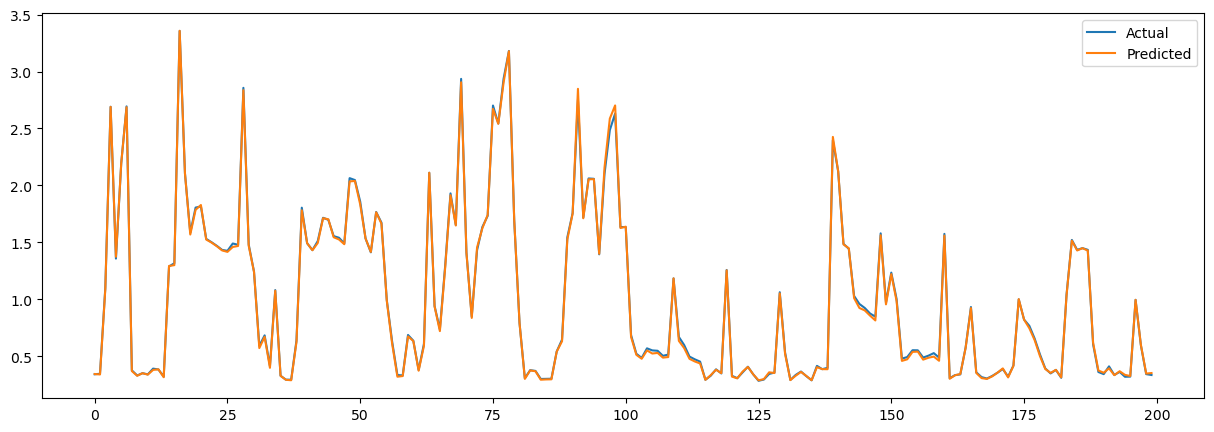

In [116]:
plt.figure(figsize=(15,5))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(y_pred[:200], label='Predicted')
plt.legend()
plt.show()

# LSTM

In [117]:
model = Sequential()
model.add(LSTM(50, return_sequences=False))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=10)

Epoch 1/10


ValueError: Input 0 with name 'None' of layer 'lstm' is incompatible with the layer: expected ndim=3, found ndim=2. Full shape received: (None, 16)